# BPIC17 vs Simulated Log Comparison

This notebook compares the original BPIC 2017 event log against a simulated event log and quantifies how well simulation approximates reality.

It focuses on:
- activity distribution similarity
- trace variant overlap
- directly-follows (DFG) overlap
- case/event counts and throughput characteristics
- start/end activity alignment

In [ ]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
if (cwd / "integration").exists():
    repo_root = cwd
elif (cwd.parent / "integration").exists():
    repo_root = cwd.parent
else:
    repo_root = cwd

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from integration.SimulationBenchmark import SimulationBenchmark

print("Repo root:", repo_root)

Repo root: D:\Repos\process-simulation-engine-1


In [ ]:
# Configure paths
ORIGINAL_LOG_PATH = repo_root / "Dataset" / "BPI Challenge 2017.xes"
SIMULATED_LOG_PATH = repo_root / "integration" / "output" / "simulated_log.csv"

print("Original log:", ORIGINAL_LOG_PATH)
print("Simulated log:", SIMULATED_LOG_PATH)

if not ORIGINAL_LOG_PATH.exists():
    raise FileNotFoundError(f"Original log not found: {ORIGINAL_LOG_PATH}")
if not SIMULATED_LOG_PATH.exists():
    raise FileNotFoundError(f"Simulated log not found: {SIMULATED_LOG_PATH}")

Original log: D:\Repos\process-simulation-engine-1\Dataset\BPI Challenge 2017.xes
Simulated log: D:\Repos\process-simulation-engine-1\integration\output\simulated_log.csv


In [ ]:
# Build benchmark (set filter_lifecycle_complete=True if you want complete-only comparison)
benchmark = SimulationBenchmark(
    original_log=str(ORIGINAL_LOG_PATH),
    simulated_log=str(SIMULATED_LOG_PATH),
    filter_lifecycle_complete=False,
)

results = benchmark.compute_all_metrics()
print("Computed benchmark sections:", list(results.keys()))

Loading original log from D:\Repos\process-simulation-engine-1\Dataset\BPI Challenge 2017.xes...
Loading simulated log from D:\Repos\process-simulation-engine-1\integration\output\simulated_log.csv...
Computing benchmark metrics...
  - Basic statistics...
  - Events per case...
  - Case throughput time...
  - Case arrivals...
  - Case completions...
  - Control flow (DFG)...
  - Trace variants...
  - Start/End activities...
  - Activity durations...
  - Overall activity distribution...
  - Simple similarity metrics...
  - Resource statistics...
Benchmark computation complete!
Computed benchmark sections: ['basic_stats', 'events_per_case', 'throughput_time', 'arrivals', 'completions', 'dfg_top', 'dfg_comparison', 'variants_top', 'variants_comparison', 'start_activities', 'end_activities', 'activity_durations', 'activity_distribution', 'simple_metrics', 'resource_stats', 'activity_resource']


In [ ]:
# Quick headline summary table
results["simple_metrics"]

,Metric,Value,Percentage
0,Activity Overlap,24 / 26 activities,92.307692
1,Activity Jaccard Similarity,0.9231,92.307692
2,Trace Variant Overlap,2 / 15930 variants,0.012555
3,Trace Variant Jaccard Similarity,0.0001,0.012519
4,Top 10 Variant Overlap,0 / 10 variants,0.000000
5,DFG Edge Overlap,66 / 178 edges,37.078652
6,DFG Edge Jaccard Similarity,0.3529,35.294118
7,Top 20 DFG Edge Overlap,15 / 20 edges,75.000000
8,Case Count Ratio,50 / 31509 cases,0.158685
9,Event Count Ratio,3399 / 1202267 events,0.282716


In [ ]:
# Core descriptive tables
results["basic_stats"]

,Log,Number of Events,Number of Cases,Number of Unique Activities,Number of Unique Resources
0,Original,1202267,31509,26,149
1,Simulated,3399,50,24,97


In [ ]:
results["events_per_case"]

,Log,Mean,Median,P90,Max
0,Original,38.156305,35.0,60.0,180
1,Simulated,67.980000,40.5,138.7,349


In [ ]:
results["throughput_time"]

,Log,Mean (hours),Median (hours),P75 (hours),P90 (hours),P95 (hours),Max (hours)
0,Original,525.590534,458.105741,755.897485,841.317475,1020.504708,6865.738515
1,Simulated,886.925688,527.123934,1076.115483,1820.896847,2605.515439,4530.159234


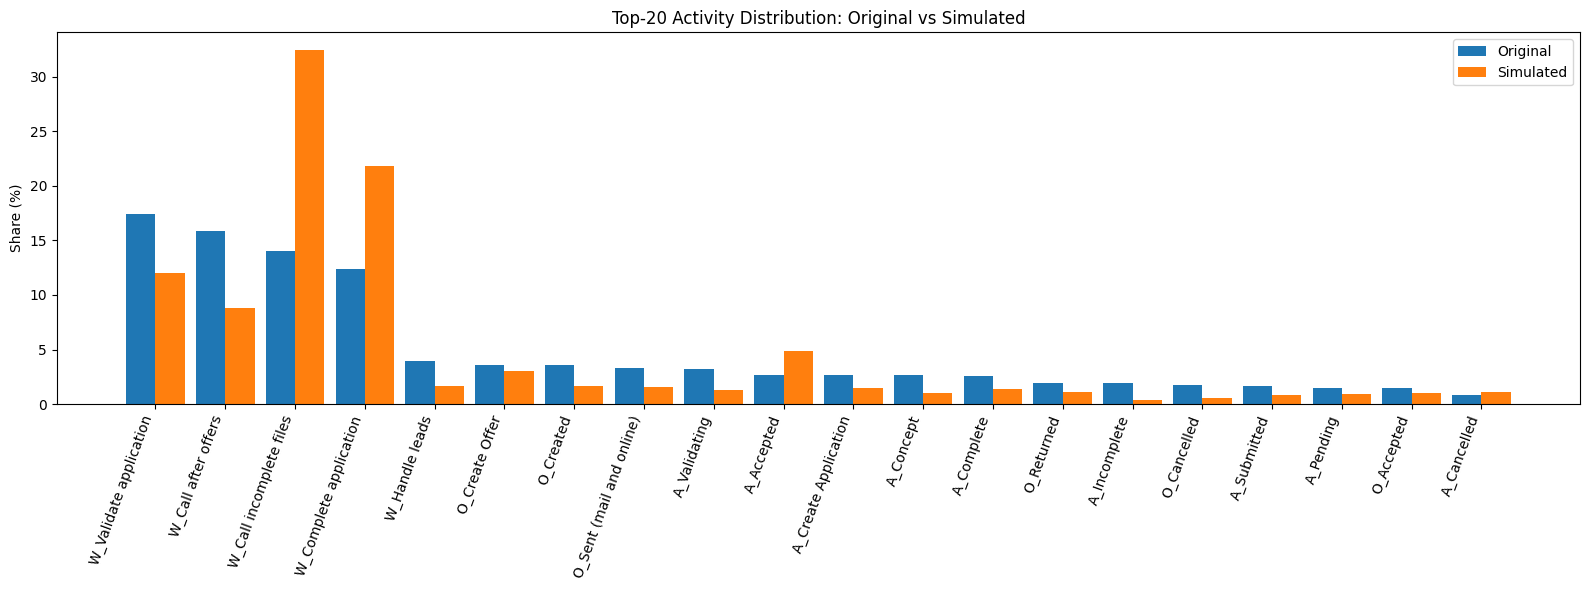

,Activity,Original Share (%),Simulated Share (%),Share Difference (%)
4,W_Validate application,17.425081,12.003530,-5.421551
18,W_Call after offers,15.894306,8.796705,-7.097601
16,W_Call incomplete files,14.017602,32.450721,18.433119
11,W_Complete application,12.384936,21.800530,9.415593
15,W_Handle leads,3.931240,1.647543,-2.283697
10,O_Create Offer,3.576161,3.000883,-0.575278
2,O_Created,3.576161,1.618123,-1.958038
6,O_Sent (mail and online),3.302677,1.588703,-1.713975
5,A_Validating,3.228567,1.323919,-1.904649
9,A_Accepted,2.620799,4.824949,2.204150


In [ ]:
# Activity distribution comparison (top-20 by original frequency)
activity_cmp = results["activity_distribution"].copy()
activity_top20 = activity_cmp.sort_values("Original Count", ascending=False).head(20)

x = np.arange(len(activity_top20))
width = 0.42

plt.figure(figsize=(16, 6))
plt.bar(x - width/2, activity_top20["Original Share (%)"], width=width, label="Original")
plt.bar(x + width/2, activity_top20["Simulated Share (%)"], width=width, label="Simulated")
plt.xticks(x, activity_top20["Activity"], rotation=70, ha="right")
plt.ylabel("Share (%)")
plt.title("Top-20 Activity Distribution: Original vs Simulated")
plt.legend()
plt.tight_layout()
plt.show()

activity_top20[["Activity", "Original Share (%)", "Simulated Share (%)", "Share Difference (%)"]]

In [ ]:
# Trace variant alignment
variants_cmp = results["variants_comparison"].copy()
variants_cmp.head(20)

,Variant,Original Count,Original Share (%),Original Rank,Simulated Count,Simulated Share (%),Simulated Rank
0,A_Create Application → A_Submitted → W_Handle ...,1056,3.351423,1.0,0,0.0,NaN
11,A_Create Application → W_Complete application ...,1021,3.240344,2.0,0,0.0,NaN
1,A_Create Application → A_Submitted → W_Handle ...,734,2.329493,3.0,0,0.0,NaN
21,A_Create Application → A_Submitted → W_Handle ...,451,1.431337,4.0,0,0.0,NaN
10,A_Create Application → A_Submitted → W_Handle ...,332,1.053667,5.0,0,0.0,NaN
7,A_Create Application → A_Submitted → W_Handle ...,298,0.945762,6.0,0,0.0,NaN
31,A_Create Application → W_Complete application ...,278,0.882288,7.0,0,0.0,NaN
27,A_Create Application → A_Submitted → W_Handle ...,244,0.774382,8.0,0,0.0,NaN
16,A_Create Application → A_Submitted → W_Handle ...,212,0.672824,9.0,0,0.0,NaN
34,A_Create Application → A_Submitted → W_Handle ...,204,0.647434,10.0,0,0.0,NaN


In [ ]:
# DFG edge alignment
results["dfg_comparison"].head(25)

,From,To,Original Count,Original Share (%),Original Rank,Simulated Count,Simulated Share (%),Simulated Rank
13,W_Validate application,W_Validate application,115590,9.873091,1.0,270,8.062108,3
34,W_Call after offers,W_Call after offers,115569,9.871297,2.0,181,5.404598,4
5,W_Call incomplete files,W_Call incomplete files,113918,9.730277,3.0,1033,30.845028,1
20,W_Complete application,W_Complete application,64695,5.525907,4.0,508,15.168707,2
26,O_Create Offer,O_Created,42995,3.672407,5.0,55,1.642281,7
8,W_Validate application,A_Validating,38816,3.315459,6.0,45,1.343685,13
6,O_Created,O_Sent (mail and online),35604,3.041107,7.0,50,1.492983,10
16,W_Complete application,W_Call after offers,31362,2.678777,8.0,54,1.612422,8
31,W_Call after offers,A_Complete,31362,2.678777,8.0,48,1.433264,11
10,O_Sent (mail and online),W_Complete application,30912,2.640341,10.0,44,1.313825,14


In [ ]:
# Start and end activities
print("Start activities")
display(results["start_activities"].head(20))

print("End activities")
display(results["end_activities"].head(20))

Start activities


,Activity,Original Count,Original Share (%),Simulated Count,Simulated Share (%)
0,A_Create Application,31509,100.0,50,100.0


End activities


,Activity,Original Count,Original Share (%),Simulated Count,Simulated Share (%)
7,W_Validate application,12662,40.185344,27,54.0
2,W_Call after offers,9457,30.013647,10,20.0
11,W_Call incomplete files,4676,14.840204,7,14.0
8,O_Cancelled,4436,14.078517,6,12.0
0,W_Complete application,144,0.457012,0,0.0
3,W_Assess potential fraud,102,0.323717,0,0.0
10,O_Sent (mail and online),15,0.047605,0,0.0
1,O_Sent (online only),8,0.025390,0,0.0
6,W_Shortened completion,5,0.015868,0,0.0
4,W_Personal Loan collection,2,0.006347,0,0.0


## Interpreting Results

Use these signals as a quick approximation scorecard:
- **Activity Jaccard Similarity**: higher means better activity coverage match.
- **Trace Variant Overlap**: higher means generated process paths resemble original paths.
- **DFG Edge Jaccard Similarity**: higher means local control-flow transitions are preserved.
- **Count Ratios (cases/events)** near 100%: simulation scale matches source log.
- **Share Difference (%)** near 0 for frequent activities: good distribution calibration.

Optional: export all benchmark tables to Excel in the next cell.

In [ ]:
# Optional export
OUT_XLSX = repo_root / "integration" / "output" / "bpic17_vs_simulation_benchmark.xlsx"
benchmark.export_results(str(OUT_XLSX))
print("Exported:", OUT_XLSX)

Results exported to D:\Repos\process-simulation-engine-1\integration\output\bpic17_vs_simulation_benchmark.xlsx
Exported: D:\Repos\process-simulation-engine-1\integration\output\bpic17_vs_simulation_benchmark.xlsx
